## **Modelagem: XGBoost**

Neste notebook vamos construir e testar um modelo de classificação XGBoost para prever os funcionários que pedirão demissão voluntária.

O XGBoost será nosso terceiro modelo e vamos compará-lo com a regressão logística e o Random Forest.

O processo de modelagem seguirá as seguintes etapas:

- **Pipeline de transformações**: vamos definir um pipeline de transformadores para preparar nossos dados.

- **Tuning do modelo**: vamos usar 10 dobras de validação cruzada para treinar e validar 150 modelos de regressão diferentes, com hiperparâmetros aleatóriamente escolhido no espaço de parâmetros possíveis. Vamos optar pelo modelo que melhor equilibra `recall` e `roc_auc`. 

- **Treinamento do melhor modelo**: vamos selecionar os hiperparâmetros do melhor modelo e treiná-lo no conjunto completo de treinamento

- **Métricas de avaliação no treinamento**: vamos avaliar a acurácia, curva ROC, precisão, recall e f1-score no conjunto de treinamento.

---

Obs: A análise da interpretabiliade será feita com o modelo final escolhido, bem como o teste no conjunto de testes. 

In [50]:
### libs ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib

### dados ###
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")["wk_status_emprego"].values

In [51]:
# tipos de variáveis
tipos_variaveis1 = {
    "numericas": ["wk_salario","wk_pesquisa_engajamento", "wk_qtd_projetos_especiais", "wk_ausencias", "sd_idade", "wk_dias_empresa"],
    "ordinais":["wk_pontuacao_desempenho", "wk_satisfacao"],
    "binarias": ["sd_sexo", "wk_atrasou_30d","sd_hispano_latino"],
    "politomicas": ["sd_estado_civil", "wk_fonte_recrutamento", "id_gestor", "wk_cargo", "sd_estado", "sd_raca", "wk_departamento"]
                   }

tipos_variaveis2 = {
    "numericas": ["wk_salario","wk_pesquisa_engajamento", "wk_qtd_projetos_especiais", "wk_ausencias", "sd_idade", "wk_dias_empresa"],
    "ordinais":["wk_pontuacao_desempenho", "wk_satisfacao"],
    "binarias": ["sd_sexo", "wk_atrasou_30d","sd_hispano_latino", "sd_estado_civil","wk_fonte_recrutamento", "sd_raca", "wk_departamento"],
    "politomicas": ["id_gestor", "wk_cargo", "sd_estado", ]
                   }

## **Transformações**

Um conjunto de transformações foi definido de acordo com o tipo de variável:

- **Numéricas:** padronizadas por escore Z -> maior estabilidade numérica. Embora seja menos necessário no RF, costuma ajudar. 

- **Ordinais:** codificação ordinal -> respeita a interpretação de ordem

- **Binárias** codificação OneHot -> similar à dummy, mas não remove uma das categorias.

- **Politômicas:** codificação pelo alvo -> evita que o número de colunas se torne muito grande

Como não haviam *missings*, um imputador não era necessário, mas, para fins de exemplo, o imputador KNN foi acrescentado ao Pipeline. 

In [52]:
# transformadores
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

# encoders igual à reg log
encoders1 = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), tipos_variaveis1["numericas"]),
        ("ordinal", OrdinalEncoder(), tipos_variaveis1["ordinais"]),
        ("binary", OneHotEncoder(sparse_output=False), tipos_variaveis1["binarias"]),
        ("politomicas", TargetEncoder(target_type="binary", cv=10), tipos_variaveis1["politomicas"])
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

# novo set de encoders
encoders2 = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), tipos_variaveis2["numericas"]),
        ("ordinal", OrdinalEncoder(), tipos_variaveis2["ordinais"]),
        ("binary", OneHotEncoder(sparse_output=False), tipos_variaveis2["binarias"]),
        ("politomicas", TargetEncoder(target_type="binary", cv=10), tipos_variaveis2["politomicas"])
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

# imputador KNN
imputer = KNNImputer(n_neighbors=10)

## **Modelo**

Um classificador `RandomForest` foi instanciado e inserido em dois pipelines distintos, a depender dos encoders usados. 

In [76]:
model = xgb.XGBClassifier(
    n_estimators=500,
    objective='binary:logistic',
    eval_metric='auc',    # Métrica de avaliação para early stopping (pode ser 'auc', 'error', etc.)
    random_state=42           # Para reprodutibilidade
)

In [77]:
# pipeline
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
      ("encoders", encoders1),
      ('imputer', imputer),
      ('clf', model)
    ])

O modelo XGBoost (Extreme Gradient Boosting) é um algoritmo poderoso e flexível, mas seu desempenho ótimo geralmente requer um ajuste cuidadoso de seus diversos hiperparâmetros. O `RandomizedSearchCV` é uma excelente ferramenta para explorar esse espaço de hiperparâmetros de forma eficiente, especialmente quando o número de combinações possíveis é grande.

A seguir, detalhamos os hiperparâmetros que serão otimizados para o classificador XGBoost (prefixado com `clf__` pois geralmente faz parte de um pipeline) e para a etapa de pré-processamento (`encoders`):

---
### Hiperparâmetros para Otimização

-   **`encoders`**: Este parâmetro permite testar diferentes configurações de pré-processamento de dados (codificadores).
    -   **Valores**: `[encoders1, encoders2]` (onde cada `encoder` representa uma estratégia distinta de transformação das features).

-   **`clf__learning_rate`** (`eta`): Escala a contribuição de cada árvore. Valores menores podem levar a uma melhor generalização, geralmente exigindo mais árvores.
    -   **Distribuição**: `loguniform(0.005, 0.3)` - Amostra valores de uma distribuição log-uniforme, ideal para parâmetros que variam em ordens de magnitude (ex: de 0.005 a 0.3).

-   **`clf__max_depth`**: Profundidade máxima de cada árvore. Controla a complexidade e o risco de overfitting.
    -   **Distribuição**: `randint(2, 6)` - Testa profundidades inteiras de 2, 3, 4 e 5.

-   **`clf__subsample`**: Fração de amostras (linhas) do conjunto de treino usadas para construir cada árvore. Ajuda a prevenir overfitting.
    -   **Distribuição**: `uniform(0.5, 0.5)` - Amostra valores de uma distribuição uniforme contínua entre 0.5 e 1.0.

-   **`clf__colsample_bytree`**: Fração de features (colunas) usadas para construir cada árvore. Similar ao `subsample`, ajuda a controlar o overfitting.
    -   **Distribuição**: `uniform(0.5, 0.5)` - Amostra valores de uma distribuição uniforme contínua entre 0.5 e 1.0.

-   **`clf__gamma`** (`min_split_loss`): Redução mínima de perda necessária para realizar uma nova divisão em um nó da árvore. Valores maiores tornam o algoritmo mais conservador.
    -   **Distribuição**: `uniform(0, 0.5)` - Amostra valores de uma distribuição uniforme contínua entre 0 e 0.5.

-   **`clf__reg_alpha`**: Termo de regularização L1 (Lasso) aplicado aos pesos das folhas. Pode induzir esparsidade (zerar pesos de features menos importantes).
    -   **Distribuição**: `loguniform(1e-3, 1e1)` - Amostra valores de uma distribuição log-uniforme entre 0.001 e 10.

-   **`clf__reg_lambda`**: Termo de regularização L2 (Ridge) aplicado aos pesos das folhas. Ajuda a prevenir overfitting tornando os pesos menores.
    -   **Distribuição**: `loguniform(1e-1, 1e2)` - Amostra valores de uma distribuição log-uniforme entre 0.1 e 100.

-   **`clf__min_child_weight`**: Soma mínima de pesos de instância (hessiana) necessária em um nó filho. Controla a complexidade e previne o overfitting em subdivisões muito específicas.
    -   **Distribuição**: `randint(1, 10)` - Testa valores inteiros de 1 a 9.

In [ ]:
from scipy.stats import uniform, randint, loguniform

param_distributions_melhorada = {
    'encoders': [encoders1, encoders2],
    'clf__learning_rate': loguniform(0.005, 0.3), 
    'clf__max_depth': randint(2, 6), 
    'clf__subsample': uniform(0.5, 0.5), 
    'clf__colsample_bytree': uniform(0.5, 0.5),
    'clf__gamma': uniform(0, 0.5), 
    'clf__reg_alpha': loguniform(1e-3, 1e1),
    'clf__reg_lambda': loguniform(1e-1, 1e2), 
    'clf__min_child_weight': randint(1, 10) 
}

In [ ]:
# randomized search cv
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=pipeline,                        # nosso pipeline
    param_distributions=param_distributions,   # grade de hiperparâmetros
    n_iter=150,                                # número máximo de modelos a tentar
    cv=10,                                     # 10 dobras de StratifiedKFold
    random_state=42,
    n_jobs=-1,                                 # usar todos os núcleos do processador
    verbose=3,                                 # resultados mais informativos do processo
    scoring=["roc_auc", "accuracy", "recall"],           # computar acurácia e roc_auc
    refit="roc_auc"                            # ajustar melhor modelo baseado na roc_auc
)

# random_search.fit(X_train, y_train)

Fitting 10 folds for each of 150 candidates, totalling 1500 fits


RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('encoders',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               StandardScaler(),
                                                                               ['wk_salario',
                                                                                'wk_pesquisa_engajamento',
                                                                                'wk_qtd_projetos_especiais',
                                                                                'wk_ausencias',
                                                                                'sd_idade',
                                                                                'wk_dias_empresa']),
                                                                              ('ordinal',
                                                                               OrdinalEncoder(),
                                                                               ['wk_pontuacao_desempenho',
                                                                                'wk_satisfacao']),
                                                                              ('binary',
                                                                               OneHotEncoder(sparse_output=Fa...
                                                                                      OneHotEncoder(sparse_output=False),
                                                                                      ['sd_sexo',
                                                                                       'wk_atrasou_30d',
                                                                                       'sd_hispano_latino',
                                                                                       'sd_estado_civil',
                                                                                       'wk_fonte_recrutamento',
                                                                                       'sd_raca',
                                                                                       'wk_departamento']),
                                                                                     ('politomicas',
                                                                                      TargetEncoder(cv=10,
                                                                                                    target_type='binary'),
                                                                                      ['id_gestor',
                                                                                       'wk_cargo',
                                                                                       'sd_estado'])],
                                                                       verbose_feature_names_out=False)]},
                   random_state=42, refit='roc_auc',
                   scoring=['roc_auc', 'accuracy', 'recall'], verbose=3)

In [80]:
# ver resultados
results_vars = [
    "mean_test_roc_auc",
    "mean_test_accuracy",
    "mean_test_recall",
    "rank_test_roc_auc",
    "rank_test_accuracy",
    "rank_test_recall"
                ]

resultados_search = pd.DataFrame(random_search.cv_results_)

resultados_search[results_vars].head(5)

,mean_test_roc_auc,mean_test_accuracy,mean_test_recall,rank_test_roc_auc,rank_test_accuracy,rank_test_recall
0,0.845051,0.834964,0.614286,145,57,102
1,0.875755,0.826449,0.614286,29,90,102
2,0.850296,0.817754,0.630952,137,123,63
3,0.854692,0.834601,0.661905,124,64,22
4,0.873288,0.817935,0.495238,39,122,143


In [81]:
# soma dos ranks
resultados_search["score"] = resultados_search.rank_test_roc_auc + resultados_search.rank_test_recall

# minimizar a soma dos ranks
resultados_search.sort_values(by="score")[results_vars].head(5)

,mean_test_roc_auc,mean_test_accuracy,mean_test_recall,rank_test_roc_auc,rank_test_accuracy,rank_test_recall
124,0.891923,0.848551,0.726190,1,17,1
117,0.886734,0.822283,0.702381,2,105,4
113,0.879871,0.830978,0.692857,17,74,5
70,0.885730,0.855978,0.673810,3,4,19
61,0.879287,0.835145,0.664286,19,54,20


O modelo "124" ficou em primeiro lugar na `roc_auc` e `recall`, portanto equilibrando bem essas métricas. 

In [82]:
# parâmetros do modelo escolhido
best_params = resultados_search["params"][124]

best_params

{'encoders': ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                  ['wk_salario', 'wk_pesquisa_engajamento',
                                   'wk_qtd_projetos_especiais', 'wk_ausencias',
                                   'sd_idade', 'wk_dias_empresa']),
                                 ('ordinal', OrdinalEncoder(),
                                  ['wk_pontuacao_desempenho', 'wk_satisfacao']),
                                 ('binary', OneHotEncoder(sparse_output=False),
                                  ['sd_sexo', 'wk_atrasou_30d',
                                   'sd_hispano_latino']),
                                 ('politomicas',
                                  TargetEncoder(cv=10, target_type='binary'),
                                  ['sd_estado_civil', 'wk_fonte_recrutamento',
                                   'id_gestor', 'wk_cargo', 'sd_estado',
                                   'sd_raca', 'wk_departamento'])],
        

In [83]:
# tempo de treinamento e pontuação do modelo escolhido
resultados_search[["mean_fit_time", "mean_score_time"]].iloc[124,]

mean_fit_time      0.264817
mean_score_time    0.051269
Name: 124, dtype: float64

## **Treinar modelo com os melhores parâmetros**

In [84]:
# definir parâmetros para o pipeline
pipeline.set_params(**best_params)

Pipeline(steps=[('encoders',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['wk_salario',
                                                   'wk_pesquisa_engajamento',
                                                   'wk_qtd_projetos_especiais',
                                                   'wk_ausencias', 'sd_idade',
                                                   'wk_dias_empresa']),
                                                 ('ordinal', OrdinalEncoder(),
                                                  ['wk_pontuacao_desempenho',
                                                   'wk_satisfacao']),
                                                 ('binary',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['sd_sexo', 'wk_atrasou_30d',
                                                   's...
                               feature_types=None, feature_weights=None,
                               gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=8, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [85]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('encoders',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['wk_salario',
                                                   'wk_pesquisa_engajamento',
                                                   'wk_qtd_projetos_especiais',
                                                   'wk_ausencias', 'sd_idade',
                                                   'wk_dias_empresa']),
                                                 ('ordinal', OrdinalEncoder(),
                                                  ['wk_pontuacao_desempenho',
                                                   'wk_satisfacao']),
                                                 ('binary',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['sd_sexo', 'wk_atrasou_30d',
                                                   's...
                               feature_types=None, feature_weights=None,
                               gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=8, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, ...))])

## **Avaliação do modelo no conjunto de treinamento**

Vamos avaliar o modelo no conjunto de treinamento

In [86]:
# classificador baseline aleatório
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="stratified", random_state=42)

dummy.fit(X_train, y_train)

DummyClassifier(random_state=42, strategy='stratified')

In [88]:
# acurácia
from sklearn.metrics import accuracy_score

acc_dummy = accuracy_score(y_train, dummy.predict(X_train))
acc_modelo = accuracy_score(y_train, pipeline.predict(X_train))

print(f"O modelo dummy obteve acurácia de {acc_dummy:.1%}")
print(f"A modelo XGB obteve acurácia de {acc_modelo:.1%}")
print(f"Isso significa que o XGB trouxe um aumento de acurácia de {acc_modelo - acc_dummy:.1%}")

O modelo dummy obteve acurácia de 59.7%
A modelo XGB obteve acurácia de 94.1%
Isso significa que o XGB trouxe um aumento de acurácia de 34.3%


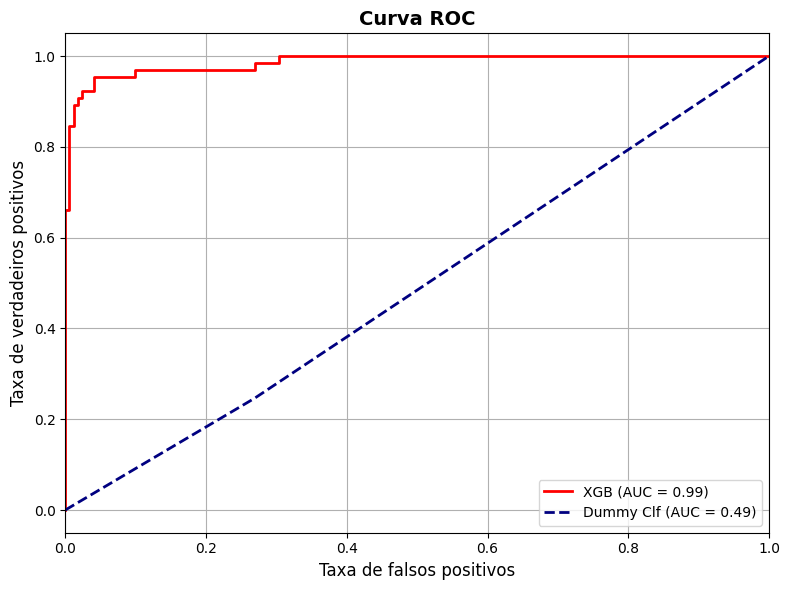

In [90]:
# curva ROC
from sklearn.metrics import roc_curve, auc
fpr_d, tpr_d, thresholds_d = roc_curve(y_train, dummy.predict_proba(X_train)[:, 1])
fpr, tpr, thresholds = roc_curve(y_train, pipeline.predict_proba(X_train)[:, 1])

# gráfico
plt.figure(figsize=(8, 6))

# Plot da curva ROC do seu Pipeline
plt.plot(fpr, tpr,
         color='red', 
         linewidth=2,
         label=f'XGB (AUC = {auc(fpr, tpr):.2f})')

# Plot da curva ROC do Dummy Classifier
plt.plot(fpr_d, tpr_d,
         color='navy', 
         linestyle='--',
         linewidth=2,
         label=f'Dummy Clf (AUC = {auc(fpr_d, tpr_d):.2f})')

# Configurações do gráfico
plt.xlim([0.0, 1.0])
plt.ylim([-0.05, 1.05])
plt.xlabel('Taxa de falsos positivos', fontsize=12)
plt.ylabel('Taxa de verdadeiros positivos', fontsize=12)
plt.title('Curva ROC', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# recall, precisão, f1_score
from sklearn.metrics import precision_score, recall_score, f1_score

prec_dummy, prec_modelo  = precision_score(y_train, dummy.predict(X_train)), precision_score(y_train, pipeline.predict(X_train))

rec_dummy, rec_modelo = recall_score(y_train, dummy.predict(X_train)), recall_score(y_train, pipeline.predict(X_train))

f1_dummy, f1_modelo = f1_score(y_train, dummy.predict(X_train)), f1_score(y_train, pipeline.predict(X_train))

print(f"O modelo dummy obteve precisão de {prec_dummy:.1%}, recall de {rec_dummy:.1%} e f1 de {f1_dummy:.1%}")
print(f"O meu XGB obteve precisão de {prec_modelo:.1%}, recall de {rec_modelo:.1%} e f1 de {f1_modelo:.1%}")

O modelo dummy obteve precisão de 25.8%, recall de 24.6% e f1 de 25.2%
O meu RF obteve precisão de 98.1%, recall de 80.0% e f1 de 88.1%


## **Endpoint**

Alcançamos um modelo XGBoost final e avaliamos ele no conjunto de treinamento. Agora vamos salvar o modelo e avaliá-lo, com os demais, em uma estratégia de validação cruzada final. 

In [92]:
# salvar objeto pipeline completo
joblib.dump(pipeline, 'xgb_pipeline_trained.joblib')

['xgb_pipeline_trained.joblib']